<a href="https://colab.research.google.com/github/seirah-yang/BootCamp/blob/main/%ED%86%B5%EA%B3%84Tool_Two_way_ANOVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 4. Two-way ANOVA

Hospital vs Pharmacy 약물 판매 차이

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")
df.head()
#'['Distributor', 'Customer Name', 'City', 'Country', 'Latitude', 'Longitude', 'Channel', 'Sub-channel',
 #'Product Name', 'Product Class', 'Quantity', 'Price', 'Sales', 'Month', 'Year', 'Name of Sales Rep',
 #'Manager', 'Sales Team']

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Świecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,Czeladź,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018,Anne Wu,Britanny Bold,Delta


In [ ]:
df.loc[df["Product Class"] == "Mood Stabilizers", "Product Name"], (df.loc[df["Product Class"] == "Analgesics", "Product Name"])

(0                   Topipizole
 5                    Pazofenac
 7         Morphizolid Tianalin
 8                      Lovapur
 10                Trazobalamin
                   ...         
 254052              Topipizole
 254060              Adriacaine
 254079                Adideine
 254080             Feruprazole
 254081             Feruprazole
 Name: Product Name, Length: 46415, dtype: object,
 3           Lioletine Refliruvax
 4         Oxymotroban Fexoformin
 6                      Symbitrim
 9                        Ampysin
 15            Neuropogen Empibax
                    ...          
 254035              Alglutriptan
 254036      Paronium Atracustone
 254042          Dantolac Pazocor
 254062              Topifribrate
 254076                Dasagestin
 Name: Product Name, Length: 44751, dtype: object)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")
set(df["Channel"].values.tolist()),set(df["Product Class"].values.tolist())

({'Hospital', 'Pharmacy'},
 {'Analgesics',
  'Antibiotics',
  'Antimalarial',
  'Antipiretics',
  'Antiseptics',
  'Mood Stabilizers'})

데이터 크기: (600, 3)
    Channel Product Class         Sales
0  Hospital    Analgesics   9289.240979
1  Hospital    Analgesics   9978.321594
2  Hospital    Analgesics  10819.426372
3  Hospital    Analgesics  10009.633405
4  Hospital    Analgesics   9345.421164
                                   sum_sq     df           F        PR(>F)
C(Channel)                   1.297496e+09    1.0  612.862207  3.078707e-93
C(Product_Class)             1.031049e+07    5.0    0.974016  4.329062e-01
C(Channel):C(Product_Class)  1.163821e+07    5.0    1.099443  3.595262e-01
Residual                     1.244860e+09  588.0         NaN           NaN

--- ANOVA 결과 해석 ---
 'C(Channel)' 요인은 유의함 (p=0.0000) → 평균에 차이 존재
 'C(Product_Class)' 요인은 유의하지 않음 (p=0.4329)
 'C(Channel):C(Product_Class)' 요인은 유의하지 않음 (p=0.3595)
 'Residual' 요인은 유의하지 않음 (p=nan)


/tmp/ipython-input-3757539632.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='Product_Class', y='Sales', hue='Channel', data=df, ci='sd', palette='Set2')


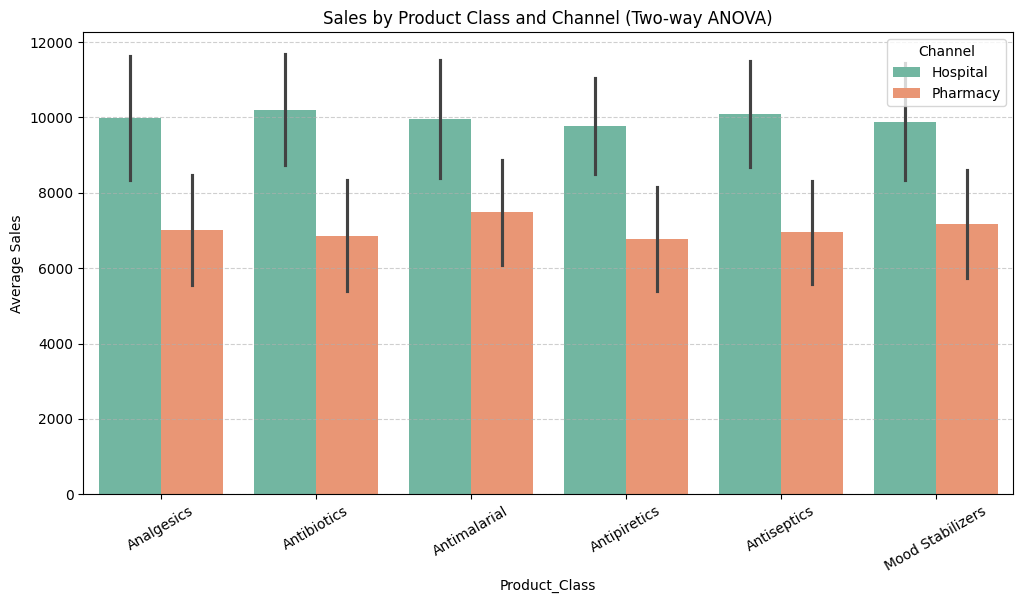

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
df = pd.read_csv("/content/drive/MyDrive/pharma-data.csv")
channels = ['Hospital', 'Pharmacy']
classes = ['Analgesics', 'Antibiotics', 'Antimalarial',
           'Antipiretics', 'Antiseptics', 'Mood Stabilizers']

# 판매량
data = []
for ch in channels:
    for c in classes:
        n = 50
        base = 10000 if ch == 'Hospital' else 7000
        sales = np.random.normal(loc=base, scale=1500, size=n)
        for s in sales:
            data.append([ch, c, s])

df = pd.DataFrame(data, columns=['Channel', 'Product Class', 'Sales'])

print(f"데이터 크기: {df.shape}")
print(df.head())

df = df.rename(columns={'Product Class': 'Product_Class'})

model = ols('Sales ~ C(Channel) * C(Product_Class)', data=df).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)


def interpret_anova(result):
    print("\n--- ANOVA 결과 해석 ---")
    for factor in result.index:
        p = result.loc[factor, 'PR(>F)']
        if p < 0.05:
            print(f" '{factor}' 요인은 유의함 (p={p:.4f}) → 평균에 차이 존재")
        else:
            print(f" '{factor}' 요인은 유의하지 않음 (p={p:.4f})")

interpret_anova(anova_result)


# 4. 시각화
plt.figure(figsize=(12,6))
sns.barplot(x='Product_Class', y='Sales', hue='Channel', data=df, ci='sd', palette='Set2')
plt.title('Sales by Product Class and Channel (Two-way ANOVA)')
plt.ylabel('Average Sales')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
